<a href="https://colab.research.google.com/github/JungYeoni/study_torch/blob/main/ML/Softmax%20Regression/%EC%86%8C%ED%94%84%ED%8A%B8%EB%A7%A5%EC%8A%A4_%ED%9A%8C%EA%B7%80_%EC%9D%B4%ED%95%B4%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 원-핫 인코딩(One-Hot Encoding)

학습 자료
> https://wikidocs.net/59678

- 선택해야 하는 선택지 개수만큼의 차원을 가지면서, 각 선택지의 인덱스에 해당하는 원소에는 1, 나머지 원소에는 0의 값을 가지도록 하는 표현 방법
- 원-핫 인코딩으로 표현된 벡터를 원-핫 벡터라고 함

## 원-핫 벡터의 무작위성

- 다중 클래스 분류 문제가 각 클래스 간의 관계가 균등하다는 점에서 적절한 표현 방법임
- 여러 카테고리에 대해서 원-핫 인코딩을 통해 레이블을 인코딩 했을 때 클래스 간의 제곱 오차가 균등함을 보여줌
- 원-핫 벡터는 클래스의 표현 방법이 무작위성을 가짐 --> 단어의 유사성을 구할 수 없음

# 소프트맥스 회귀(Softmax Regression) 이해하기

학습 자료
> https://wikidocs.net/59427

- 3개 이상의 선택지 중에서 1개를 고르는 다중 클래스 분류

로지스틱 회귀

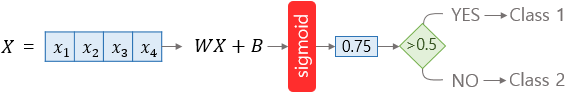

- 시그모이드 함수는 예측값을 0과 1사이의 값으로 만듦

소프트맥스 회귀

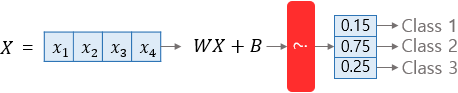

- 소프트맥스 회귀는 확률의 총 합이 1이 되는 아이디어를 다중 클래스 분류 문제에 적용
- 각 클래스마다 소수 확률을 할당 -> 각 선택지가 정답일 확률로 표현됨

## 소프트맥스 함수

- 분류해야하는 클래스의 총 개수를 k개라고 할 때, k차원의 벡터를 입력받아 각 클래스에 대한 확률을 추정함

$ softmax(z)=[\frac{e^{z_{1}}}{\sum_{j=1}^{3} e^{z_{j}}}\ \frac{e^{z_{2}}}{\sum_{j=1}^{3} e^{z_{j}}}\ \frac{e^{z_{3}}}{\sum_{j=1}^{3} e^{z_{j}}}] = [p_{1}, p_{2}, p_{3}] = \hat{y} = \text{예측값} $

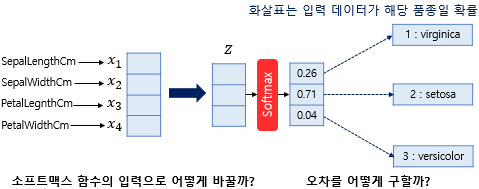

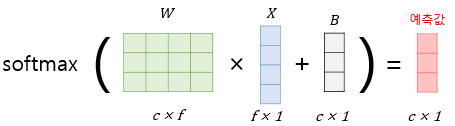

## 비용 함수

- 크로스 엔트로피 함수를 사용함
- 최종 비용 함수에서 k=2 라고 가정하면 로지스틱 회귀의 비용 함수와 동일함

# 소프트맥스 회귀 다양한 방법으로 구현하기

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [46]:
torch.manual_seed(1)

## 파이토치로 소프트맥스의 비용 함수 구현하기 (low-level)

In [47]:
# 3개의 원소를 가진 벡터 텐서 정의
z = torch.FloatTensor([1, 2, 3])

In [48]:
# 위의 텐서를 소프트맥스 함수의 입력으로 사용
hypothesis = F.softmax(z, dim=0)
print(hypothesis)

tensor([0.0900, 0.2447, 0.6652])


0과 1사이의 값을 가지는 벡터로 전환된 것을 확인할 수 있음

In [49]:
# 원소들의 합이 1인지 확인
hypothesis.sum()

tensor(1.)

In [50]:
# 임의의 3x5 행렬의 크기를 가진 텐서 생성
z = torch.rand(3, 5, requires_grad=True)

In [51]:
# 텐서에 소프트맥스 함수 적용
hypothesis = F.softmax(z, dim=0)
print(hypothesis)

tensor([[0.3412, 0.2938, 0.2671, 0.4002, 0.2469],
        [0.3559, 0.3306, 0.3796, 0.3393, 0.3719],
        [0.3029, 0.3756, 0.3533, 0.2605, 0.3812]], grad_fn=<SoftmaxBackward0>)


In [52]:
# 각 샘플에 대해서 임의의 레이블 만들기
y = torch.randint(5, (3, )).long()
print(y)

tensor([0, 2, 1])


In [53]:
# 모든 원소가 0의 값을 가진 원-핫 인코딩 수행
y_one_hot = torch.zeros_like(hypothesis) # 0의 값을 가진 3x5 텐서
y_one_hot.scatter_(1, y.unsqueeze(1), 1) # (3,)의 크기를 가진 텐서는 (3, 1) 텐서가 됨.

tensor([[1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.]])

In [54]:
print(y.unsqueeze(1))

tensor([[0],
        [2],
        [1]])


In [55]:
print(y_one_hot)

tensor([[1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.]])


In [56]:
# 비용 함수 구현하기
cost = (y_one_hot * - torch.log(hypothesis)).sum(dim=1).mean()
print(cost)

tensor(1.0078, grad_fn=<MeanBackward0>)


## 파이토치로 소프트맥스의 비용 함수 구현하기 (high-level)

In [57]:
# low level
torch.log(F.softmax(z, dim=1)) # 소프트맥스 함수의 출력값을 로그 함수의 입력으로 사용

tensor([[-1.3301, -1.8084, -1.6846, -1.3530, -2.0584],
        [-1.4147, -1.8174, -1.4602, -1.6450, -1.7758],
        [-1.5025, -1.6165, -1.4586, -1.8360, -1.6776]], grad_fn=<LogBackward0>)

In [58]:
# high level
F.log_softmax(z, dim=1)

tensor([[-1.3301, -1.8084, -1.6846, -1.3530, -2.0584],
        [-1.4147, -1.8174, -1.4602, -1.6450, -1.7758],
        [-1.5025, -1.6165, -1.4586, -1.8360, -1.6776]],
       grad_fn=<LogSoftmaxBackward0>)

In [59]:
# low level
# 첫번째 수식
(y_one_hot * - torch.log(F.softmax(z, dim=1))).sum(dim=1).mean()

tensor(1.4689, grad_fn=<MeanBackward0>)

In [60]:
# 두번째 수식
(y_one_hot * -F.log_softmax(z, dim=1)).sum(dim=1).mean()

tensor(1.4689, grad_fn=<MeanBackward0>)

In [61]:
# high level
# 세번째 수식 (nll: negativre log likeihood)
F.nll_loss(F.log_softmax(z, dim=1), y)

tensor(1.4689, grad_fn=<NllLossBackward0>)

In [62]:
# 네번째 수식
# F.cross_entropy는 비용 함수에 소프트맥스 함수까지 포함
# one-hot 을 안쓰는 이유: cross_entropy는 내부적으로 정답 클래스 위치만 골라서 계산
F.cross_entropy(z, y)

tensor(1.4689, grad_fn=<NllLossBackward0>)

## nn.CrossEntropyLoss(): 클래스를 이용한 구현 방식

In [63]:
nn.CrossEntropyLoss()(z, y)

tensor(1.4689, grad_fn=<NllLossBackward0>)

- `F.cross_entropy()`는 함수  
  - 호출할 때 마다 `F.cross_entropy(입력, 정답)` 형태로 사용함
  - 매번 호출 시 필요한 설정을 인자로 전달해야함
- `nn.CrossEntropyLoss()`는 클래스
  - 클래스는 설정값들을 저장할 수 있는 틀
  - 클래스로부터 실제 사용할 수 있는 객체를 미리 생성해야함
  - 객체를 만들 때 설정값들을 미리 정해두고, 계속 재사용 가능
  - !정답을 정수형 인덱스(LongTensor)로 받아야함

In [64]:
# 아래와 같이 사용하는 경우가 보편적

# 1단계: 클래스로 객체 생성
criterion = nn.CrossEntropyLoss()

# 2단계: 생성된 객체 사용
loss = criterion(z, y)
print(loss)

tensor(1.4689, grad_fn=<NllLossBackward0>)


In [68]:
# 손실함수 객체를 한 번만 생성함
# 이제 호출할 때는 무조건 criterion으로만 호출

criterion = nn.CrossEntropyLoss()

# 같은 객체로 여러 번 계산 가능
loss1 = criterion(z, y) # 첫 번째 계산
loss2 = criterion(z, y) # 두 번째 계산

# 새로운 데이터가 있다면
z2 = torch.rand(3, 5, requires_grad=True)
y2 = torch.randint(5, (3, )).long() # long을 통해 dtype을 torch.int64로 바꿔줌 (정수형 인덱스로 변환)
loss3 = criterion(z2, y2) # 새 데이터로 계산

In [69]:
# 손실값의 평균 대신 합계가 필요한 경우

# 손실함수 객체 생성
criterion = nn.CrossEntropyLoss(reduction='sum')

# 같은 객체로 여러번 계산 가능
loss1 = criterion(z, y)
loss2 = criterion(z, y)

# 새로운 데이터
z2 = torch.rand(3, 5, requires_grad=True)
y2 = torch.randint(5, (3, )).long()
loss3 = criterion(z2, y2)

In [70]:
#  함수 방식에서는 매번 설정 반복
loss_sum1 = F.cross_entropy(z, y, reduction='sum')
loss_sum2 = F.cross_entropy(z2, y2, reduction='sum')

# 소프트맥스 회귀 구현하기

In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [86]:
torch.manual_seed(1)

In [87]:
# 데이터셋 준비
x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 1, 5, 5],
           [1, 7, 5, 5],
           [1, 2, 5, 6],
           [1, 6, 6, 6],
           [1, 7, 7, 7]]
y_train = [2, 2, 2, 1, 1, 1, 0, 0]
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)

## low-level로 구현하기

In [88]:
# 데이터 크기 확인
print(x_train.shape)
print(y_train.shape)

torch.Size([8, 4])
torch.Size([8])


최종에서 사용할 레이블은 y_train 에서 원-핫 인코딩을 한 결과여야함

In [89]:
y_one_hot = torch.zeros(8, 3)
y_one_hot.scatter_(1, y_train.unsqueeze(1), 1)
print(y_one_hot.shape)

torch.Size([8, 3])


In [90]:
# 모델 초기화
W = torch.zeros((4, 3), requires_grad=True)
b = torch.zeros((1, 3), requires_grad=True)

# optimizer 설정
optimizer = optim.SGD([W, b], lr=0.1)

In [91]:
nb_epochs = 1000

for epoch in range(nb_epochs + 1):
  hypothesis = F.softmax(x_train.matmul(W) + b, dim=1)
  cost = (y_one_hot * -torch.log(hypothesis)).sum(dim=1).mean()

  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print('Epoch {:4d}/{} Cost: {:.6f}'.format(
        epoch, nb_epochs, cost.item()))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.622999
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467661
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285072
Epoch 1000/1000 Cost: 0.248155


## high-level로 구현하기

In [92]:
# 모델 초기화
W = torch.zeros((4, 3), requires_grad=True)
b = torch.zeros((1, 3), requires_grad=True)

# optimizer 설정
optimizer = optim.SGD([W, b], lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):
  # cost 계산
  z = x_train.matmul(W) + b
  cost = F.cross_entropy(z, y_train)

  # cost로 H(x) 개선
  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  # 100번마다 로그 출력
  if epoch % 100 == 0:
    print('Epoch {:4d}/{} Cost: {:.6f}'.format(
        epoch, nb_epochs, cost.item()
    ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.623000
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467662
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285073
Epoch 1000/1000 Cost: 0.248155


## nn.Module로 구현하기

In [93]:
# 모델 선언 및 초기화 - 4개의 특성을 가지고 3개의 클래스로 분류
model = nn.Linear(4, 3)

In [101]:
# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr=0.01)

nb_epochs = 1000

for epoch in range(nb_epochs + 1):

  # H(x) 계산
  prediction = model(x_train)

  # cost 계산
  cost = F.cross_entropy(prediction, y_train)

  # cost로 H(x) 개선
  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  # 20번마다 로그 출력
  if epoch % 100 == 0:
    print(
        'Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item())
    )

Epoch    0/1000 Cost: 0.254438
Epoch  100/1000 Cost: 0.247106
Epoch  200/1000 Cost: 0.245783
Epoch  300/1000 Cost: 0.244473
Epoch  400/1000 Cost: 0.243178
Epoch  500/1000 Cost: 0.241896
Epoch  600/1000 Cost: 0.240627
Epoch  700/1000 Cost: 0.239371
Epoch  800/1000 Cost: 0.238128
Epoch  900/1000 Cost: 0.236897
Epoch 1000/1000 Cost: 0.235679


## 클래스로 구현하기

In [97]:
class SoftmaxClassifierModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(4, 3)

  def forward(self, x):
    return self.linear(x)

In [99]:
model = SoftmaxClassifierModel()

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [100]:
nb_epochs = 1000
for epoch in range(nb_epochs + 1):
  prediction = model(x_train)
  cost = F.cross_entropy(prediction, y_train) # 아직 소프트맥스를 거치지 않은 상태

  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print('Epoch {:4d}/{} Cost: {:.6f}'.format(
        epoch, nb_epochs, cost.item()
    ))

Epoch    0/1000 Cost: 1.366217
Epoch  100/1000 Cost: 0.722726
Epoch  200/1000 Cost: 0.637564
Epoch  300/1000 Cost: 0.578576
Epoch  400/1000 Cost: 0.527363
Epoch  500/1000 Cost: 0.479316
Epoch  600/1000 Cost: 0.432700
Epoch  700/1000 Cost: 0.386693
Epoch  800/1000 Cost: 0.340930
Epoch  900/1000 Cost: 0.295757
Epoch 1000/1000 Cost: 0.255350
